In [1]:
import pandas as pd
import numpy as np

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("imdb_details.csv")

# Display first rows
df.head()

,number,title,rating,nbr_votes,description,season
0,1,Rose,7.6,6504,When ordinary shop-worker Rose Tyler meets a m...,1
1,2,The End of the World,7.6,5684,The Doctor takes Rose to the year 5 billion to...,1
2,3,The Unquiet Dead,7.6,5326,The Doctor has great expectations for his late...,1
3,4,Aliens of London,7.0,5116,The Doctor returns Rose to her own time - well...,1
4,5,World War Three,7.1,4943,The Slitheen have infiltrated Parliament and h...,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   number       148 non-null    int64  
 1   title        148 non-null    str    
 2   rating       148 non-null    float64
 3   nbr_votes    148 non-null    int64  
 4   description  148 non-null    str    
 5   season       148 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 41.6 KB


In [5]:
possible_columns = [
    'overview',
    'description',
    'plot',
    'review',
    'story',
    'summary'
]

text_column = None

for col in possible_columns:
    if col in df.columns:
        text_column = col
        break

print("Using text column:", text_column)

Using text column: description


In [6]:
df.columns

Index(['number', 'title', 'rating', 'nbr_votes', 'description', 'season'], dtype='str')

In [7]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    # Remove numbers and symbols
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


df['clean_text'] = df[text_column].apply(clean_text)

df[['clean_text']].head()

,clean_text
0,ordinary shop worker rose tyler meet mysteriou...
1,doctor take rose year billion witness destruct...
2,doctor great expectation latest adventure rose...
3,doctor return rose time well sort family reuni...
4,slitheen infiltrated parliament doctor friend ...


In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])

print(X.shape)

(148, 4098)


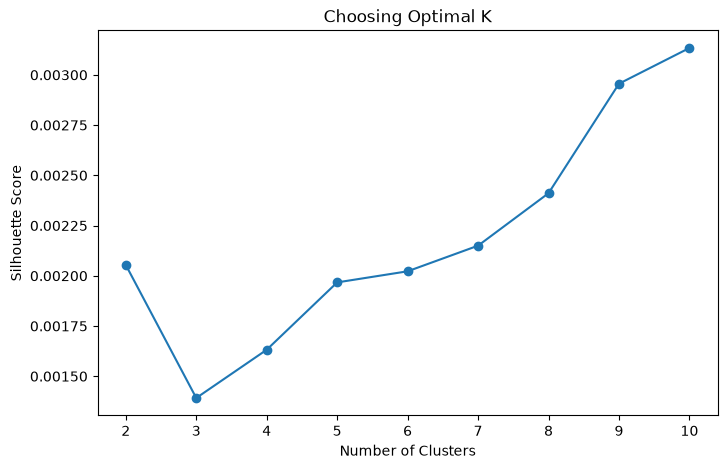

In [9]:
scores = []

K = range(2,11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    scores.append(score)


plt.figure(figsize=(8,5))

plt.plot(K, scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Choosing Optimal K")

plt.show()

In [10]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X)

df.head()

,number,title,rating,nbr_votes,description,season,clean_text,cluster
0,1,Rose,7.6,6504,When ordinary shop-worker Rose Tyler meets a m...,1,ordinary shop worker rose tyler meet mysteriou...,0
1,2,The End of the World,7.6,5684,The Doctor takes Rose to the year 5 billion to...,1,doctor take rose year billion witness destruct...,1
2,3,The Unquiet Dead,7.6,5326,The Doctor has great expectations for his late...,1,doctor great expectation latest adventure rose...,2
3,4,Aliens of London,7.0,5116,The Doctor returns Rose to her own time - well...,1,doctor return rose time well sort family reuni...,2
4,5,World War Three,7.1,4943,The Slitheen have infiltrated Parliament and h...,1,slitheen infiltrated parliament doctor friend ...,3


In [11]:
for i in range(k):

    print("\n====================")
    print("Cluster:", i)
    print("====================")

    movies = df[df['cluster']==i]

    display(
        movies.head(10)
    )


Cluster: 0


,number,title,rating,nbr_votes,description,season,clean_text,cluster
0,1,Rose,7.6,6504,When ordinary shop-worker Rose Tyler meets a m...,1,ordinary shop worker rose tyler meet mysteriou...,0
23,10,Love & Monsters,6.2,5738,Elton Pope is an ordinary man intrigued by the...,2,elton pope ordinary man intrigued world doctor...,0
34,7,42,7.5,4458,On a spaceship headed straight for the centre ...,3,spaceship headed straight centre sun doctor mi...,0
40,13,Last of the Time Lords,8.4,5541,It's been a year since The Master unleashed th...,3,year since master unleashed mysterious toclafa...,0
45,4,The Sontaran Stratagem,7.5,4232,UNIT's newest recruit Martha Jones enlists The...,4,unit newest recruit martha jones enlists docto...,0
48,7,The Unicorn and the Wasp,7.8,4667,With a 1926 dinner party turning into a murder...,4,dinner party turning murder mystery doctor don...,0
55,1,The Eleventh Hour,8.8,6254,"With his TARDIS in ruins, the newly-regenerate...",5,tardis ruin newly regenerated doctor help amy ...,0
56,2,The Beast Below,7.6,4837,The Doctor takes Amy to the future inside Star...,5,doctor take amy future inside starship uk cont...,0
59,5,Flesh and Stone,8.6,4795,"The Doctor, Amy, Dr. Song and the remaining so...",5,doctor amy dr song remaining soldier manage es...,0
60,6,The Vampires of Venice,7.1,4491,The Doctor and Amy cross swords in more ways t...,5,doctor amy cross sword way one horde blood suc...,0



Cluster: 1


,number,title,rating,nbr_votes,description,season,clean_text,cluster
1,2,The End of the World,7.6,5684,The Doctor takes Rose to the year 5 billion to...,1,doctor take rose year billion witness destruct...,1
5,6,Dalek,8.7,5636,The TARDIS is drawn to an alien museum deep be...,1,tardis drawn alien museum deep utah desert rut...,1
6,7,The Long Game,7.2,4872,"In the year 200,000 the Doctor discovers that ...",1,year doctor discovers satellite dark secret co...,1
7,8,Father's Day,8.4,5433,"All of her life, Rose's mother told how great ...",1,life rose mother told great man father pete ki...,1
12,13,The Parting of the Ways,9.1,5788,As the Dalek fleet begin their attack on the E...,1,dalek fleet begin attack earth doctor ally mak...,1
14,1,New Earth,7.5,4891,The Doctor and Rose arrive on New Earth and me...,2,doctor rose arrive new earth meet old friend e...,1
19,6,The Age of Steel,7.9,4636,The Cybermen take control of London as the pop...,2,cybermen take control london population enslav...,1
20,7,The Idiot's Lantern,6.9,4814,"As the coronation of Elizabeth II nears, the s...",2,coronation elizabeth ii nears street london li...,1
25,12,Army of Ghosts,8.5,4885,When ghosts of loved ones appear all over the ...,2,ghost loved one appear world doctor trace phen...,1
26,13,Doomsday,9.3,6836,Earth becomes a battleground for the Daleks an...,2,earth becomes battleground daleks cybermen who...,1



Cluster: 2


,number,title,rating,nbr_votes,description,season,clean_text,cluster
2,3,The Unquiet Dead,7.6,5326,The Doctor has great expectations for his late...,1,doctor great expectation latest adventure rose...,2
3,4,Aliens of London,7.0,5116,The Doctor returns Rose to her own time - well...,1,doctor return rose time well sort family reuni...,2
8,9,The Empty Child,9.2,6659,When a spaceship crashes in the middle of the ...,1,spaceship crash middle london blitz doctor ros...,2
9,10,The Doctor Dances,9.1,6108,The gas mask zombies are on the rise as the pl...,1,gas mask zombie rise plague spread across war ...,2
10,11,Boom Town,7.2,4631,Stopping off in present-day Cardiff to recharg...,1,stopping present day cardiff recharge tardis d...,2
15,2,Tooth and Claw,7.9,5041,The Doctor and Rose are transported to 19th Ce...,2,doctor rose transported th century scotland me...,2
17,4,The Girl in the Fireplace,9.3,8504,"The Doctor, Mickey and Rose land on a spaceshi...",2,doctor mickey rose land spaceship st century f...,2
18,5,Rise of the Cybermen,7.8,4688,The TARDIS crash lands in London on a parallel...,2,tardis crash land london parallel world rose d...,2
21,8,The Impossible Planet,8.7,5399,When the Doctor and Rose become stranded on a ...,2,doctor rose become stranded planet orbiting bl...,2
24,11,Fear Her,6.1,5047,When children vanish into thin air in 2012 Lon...,2,child vanish thin air london doctor rose find ...,2



Cluster: 3


,number,title,rating,nbr_votes,description,season,clean_text,cluster
4,5,World War Three,7.1,4943,The Slitheen have infiltrated Parliament and h...,1,slitheen infiltrated parliament doctor friend ...,3
11,12,Bad Wolf,8.7,5314,The TARDIS team is separated and forced to com...,1,tardis team separated forced compete twisted d...,3
16,3,School Reunion,8.4,5397,The Krillitanes - aliens with a mix-and-match ...,2,krillitanes alien mix match physiology trying ...,3
28,1,Smith and Jones,8.0,4869,When the hospital she works at is transported ...,3,hospital work transported moon medical student...,3
33,6,The Lazarus Experiment,6.7,4652,The famous Dr Lazarus has appeared to discover...,3,famous dr lazarus appeared discover secret ete...,3
36,9,The Family of Blood,9.2,6456,The Doctor must deal with the repercussions of...,3,doctor must deal repercussion decision become ...,3
44,3,Planet of the Ood,8.1,4737,Finding themselves on the Ood-Sphere planet in...,4,finding ood sphere planet nd century doctor do...,3
49,8,Silence in the Library,9.4,6979,The Doctor and Donna join a group of archaeolo...,4,doctor donna join group archaeologist st centu...,3
65,11,The Lodger,8.3,4737,No sooner does the TARDIS land on Earth that i...,5,sooner tardis land earth leaf without doctor s...,3
88,6,The Snowmen,8.5,5154,"London, 1892. Snow is trying to evolve, feedin...",7,london snow trying evolve feeding nightmare li...,3



Cluster: 4


,number,title,rating,nbr_votes,description,season,clean_text,cluster
13,0,The Christmas Invasion,8.2,5291,"It's Christmas Eve, but this is to be a far fr...",2,christmas eve far silent night cruel sycorax c...,4
22,9,The Satan Pit,8.8,5609,The Doctor risks his life to investigate the p...,2,doctor risk life investigate pit forced make t...,4
37,10,Blink,9.8,16398,Sally Sparrow receives a cryptic message from ...,3,sally sparrow receives cryptic message doctor ...,4
82,0,"The Doctor, the Widow and the Wardrobe",7.3,4240,"It's Christmas Eve, 1938, when Madge Arwell co...",7,christmas eve madge arwell come aid injured sp...,4
110,1,The Magician's Apprentice,8.5,4716,When the skies of Earth are frozen by a myster...,9,sky earth frozen mysterious alien force clara ...,4
114,5,The Girl Who Died,7.7,3733,"In a Viking village, a girl named Ashildr is a...",9,viking village girl named ashildr make despera...,4
133,10,The Eaters of Light,7.0,2494,"A long time ago, the Roman legion of the ninth...",10,long time ago roman legion ninth vanished mist...,4
137,1,The Woman Who Fell to Earth,7.1,8066,"In a South Yorkshire city, Ryan Sinclair, Yasm...",11,south yorkshire city ryan sinclair yasmin khan...,4
140,4,Arachnids in the UK,5.3,5112,"The Doctor, Yaz, Graham, and Ryan find their w...",11,doctor yaz graham ryan find way back yorkshire...,4
141,5,The Tsuranga Conundrum,5.2,4684,Injured and stranded in the wilds of a far-flu...,11,injured stranded wild far flung galaxy doctor ...,4


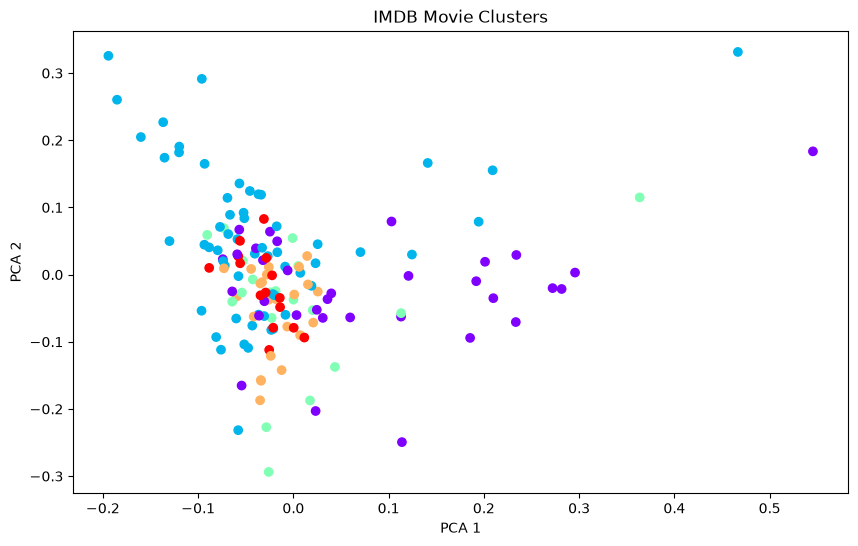

In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())


plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['cluster'],
    cmap='rainbow'
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("IMDB Movie Clusters")

plt.show()

In [13]:
terms = tfidf.get_feature_names_out()

for i in range(k):

    print("\nCluster", i)

    center = kmeans.cluster_centers_[i]

    top_words = center.argsort()[-15:]

    print(
        [terms[j] for j in top_words]
    )


Cluster 0
['board', 'race', 'doctor help', 'known', 'doctor amy', 'find', 'ship', 'time', 'help', 'amy rory', 'save', 'tardis', 'rory', 'doctor', 'amy']

Cluster 1
['make', 'greatest', 'one', 'planet', 'old friend', 'clara', 'doctor take', 'new', 'enemy', 'earth', 'face', 'friend', 'take', 'old', 'doctor']

Cluster 2
['doctor clara', 'inside', 'century', 'zombie', 'jack', 'clara find', 'middle', 'plague', 'london', 'crash', 'doctor rose', 'spaceship', 'doctor', 'rose', 'find']

Cluster 3
['student', 'library', 'something', 'game', 'become', 'trying', 'station', 'secret', 'trapped', 'bill nardole', 'nardole', 'doctor bill', 'discover', 'doctor', 'bill']

Cluster 4
['life', 'sky', 'galaxy', 'need', 'far', 'message', 'christmas', 'earth', 'home', 'doctor', 'graham yaz', 'mysterious', 'yaz', 'graham', 'ryan']


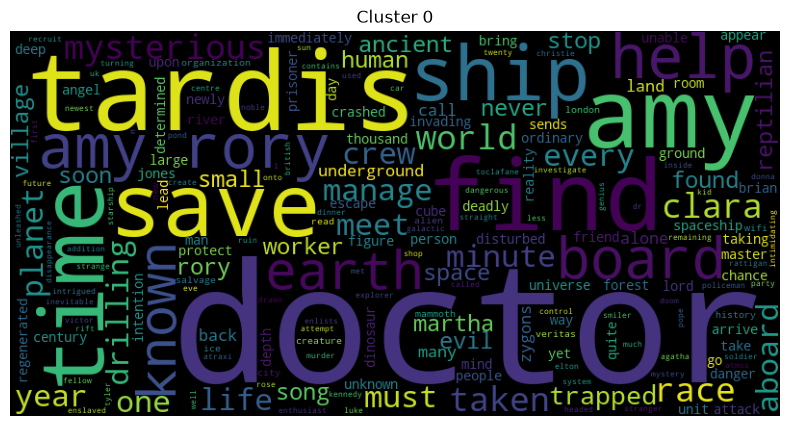

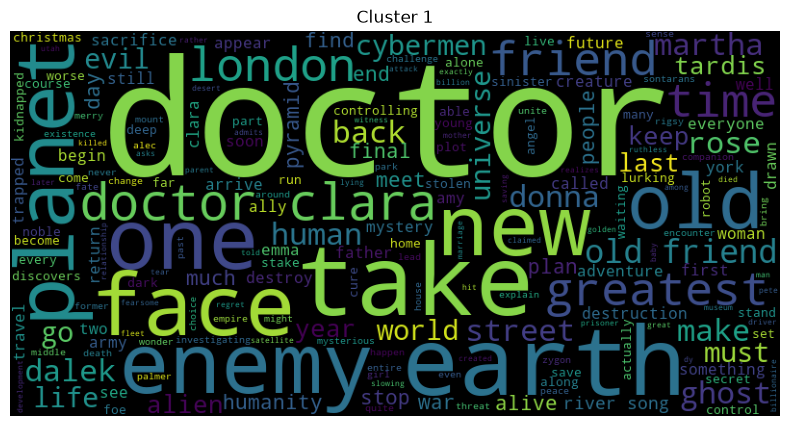

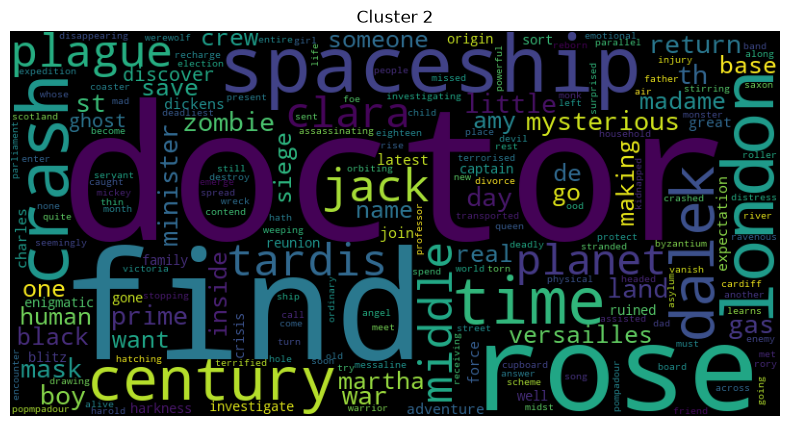

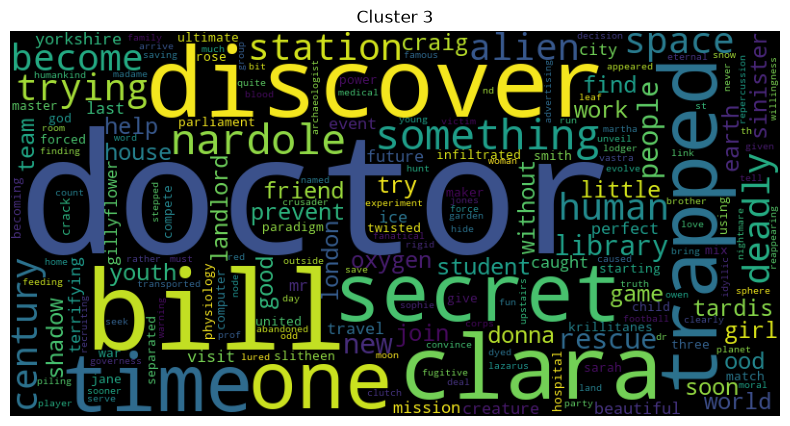

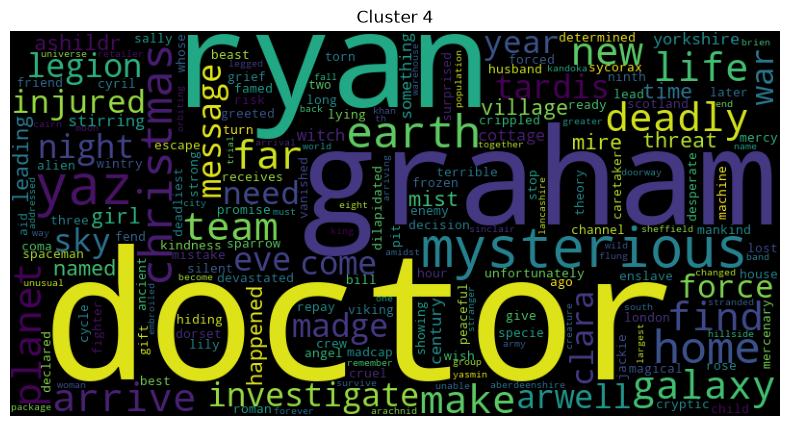

In [14]:
for i in range(k):

    text = " ".join(
        df[df.cluster==i]['clean_text']
    )

    wordcloud = WordCloud(
        width=800,
        height=400
    ).generate(text)


    plt.figure(figsize=(10,5))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title(f"Cluster {i}")

    plt.show()

In [15]:
df.to_csv(
    "imdb_kmeans_clusters.csv",
    index=False
)